In [175]:
import pandas as pd
import matplotlib.pyplot as plt 
athletes= pd.read_csv("../data/raw/athlete_events.csv")
noc= pd.read_csv("../data/raw/noc_regions.csv")

In [176]:
noc=noc.drop(columns=["notes"])
athletes =athletes.drop_duplicates()
athletes = athletes.merge(noc,on="NOC",how="left")
athletes.to_csv("../data/processed/athletes_merged.csv", index=False)

In [177]:
winners=athletes[athletes['Medal'].notnull()]
unique_medals = winners.drop_duplicates(["region", "Year", "Event", "Medal"])
winners_by_country=unique_medals.groupby(["region"])
top_10_winning_countries=winners_by_country.size().sort_values(ascending=False).head(10)


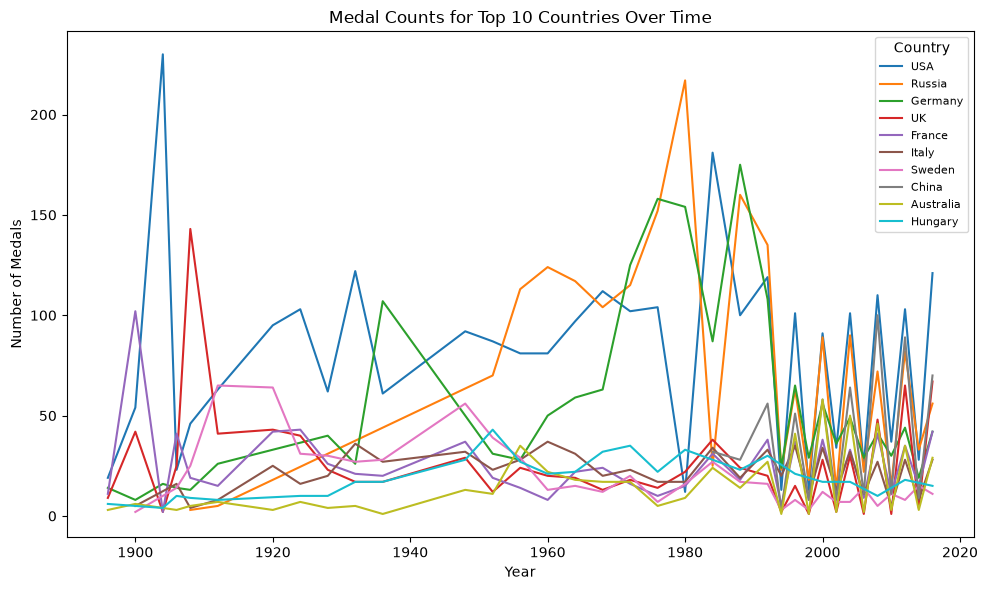

In [178]:
# medal counts for top countries over time.
winners=athletes[athletes['Medal'].notnull()]
winners = winners.drop_duplicates(["region", "Year", "Event", "Medal"])
unique_medals= winners.groupby(["region","Year"])
unique_medals=unique_medals.size().reset_index().rename(columns={0:"numbers_of_medals"})
unique_medals
countries_names=top_10_winning_countries.index
plt.figure(figsize=(10, 6))

for country in countries_names:
    data_country = unique_medals[unique_medals["region"] == country]
    plt.plot(data_country["Year"], data_country["numbers_of_medals"], label=country)

plt.title("Medal Counts for Top 10 Countries Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Medals")
plt.legend(title="Country", fontsize=8)

plt.tight_layout()
plt.savefig("../images/medal_trends.png", dpi=150)
plt.show()

In [179]:
athletes_by_gender=athletes.groupby(["Sex","Year"])
participation_by_gender_year=athletes_by_gender.size().reset_index()
participation_by_gender_year = participation_by_gender_year.rename(columns={0:"number_of_participant"})


In [180]:
athletes_sports = athletes.groupby(["Sport"])
sport_counts=athletes_sports.size().sort_values(ascending=False).reset_index()
sport_counts=sport_counts.rename(columns={0:"num_athletes"})

In [181]:
athletes_by_sport_stats = athletes.groupby("Sport")[["Age", "Height", "Weight"]].mean()

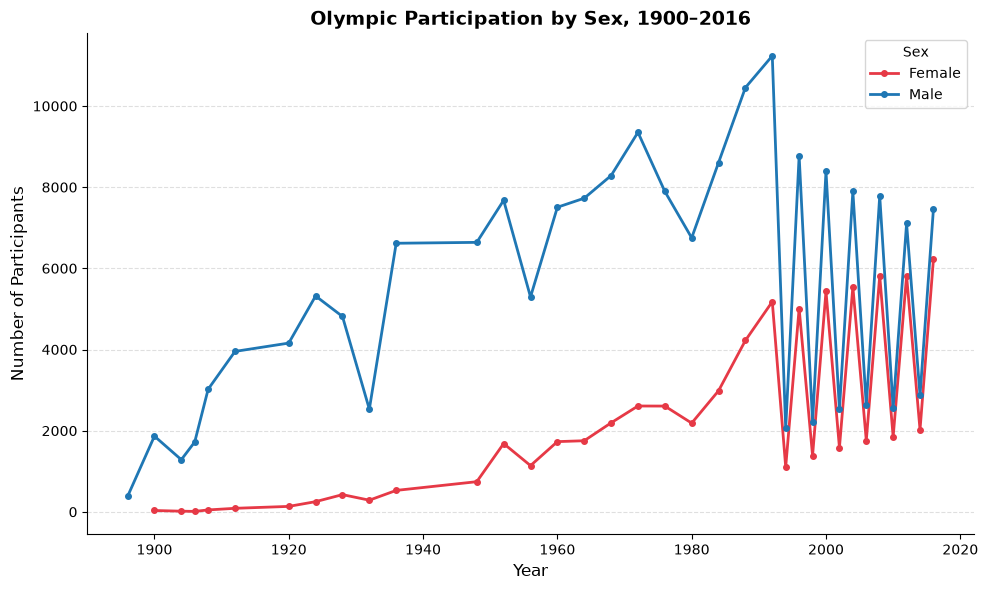

In [182]:
# Visualise participation by genders over time
plt.figure(figsize=(10, 6))

colors = {"M": "#1f77b4", "F": "#e63946"}
labels = {"M": "Male", "F": "Female"}

for gender in participation_by_gender_year["Sex"].unique():
    data_by_gender = participation_by_gender_year[participation_by_gender_year["Sex"] == gender]
    plt.plot(
        data_by_gender["Year"],
        data_by_gender["number_of_participant"],
        marker="o",
        markersize=4,
        linewidth=2,
        color=colors[gender],
        label=labels[gender]
    )

plt.title("Olympic Participation by Sex, 1900–2016", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Participants", fontsize=12)
plt.legend(title="Sex", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.4)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../images/participation_by_gender.png", dpi=150, bbox_inches="tight")
plt.show()

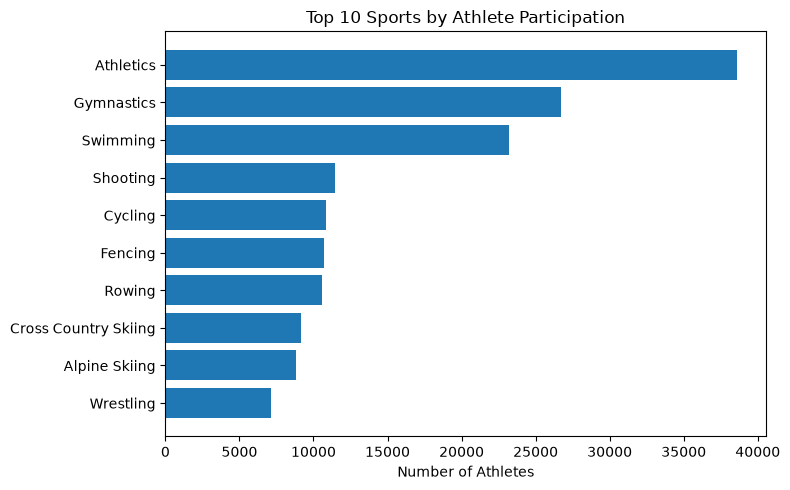

In [183]:
# Top sports by athlete count (data ready: sport_counts)

top_sports = sport_counts.head(10).sort_values("num_athletes", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(top_sports["Sport"], top_sports["num_athletes"])

plt.title("Top 10 Sports by Athlete Participation")
plt.xlabel("Number of Athletes")

plt.tight_layout()
plt.savefig("../images/top_sports.png", dpi=150)
plt.show()